In [62]:
from edges_analysis import Level1
from edges_analysis import Level2
from edges_io import io
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2
from edges_analysis.analysis import tools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
l2_data_cut = Level2('/data4/nmahesh/edges/edges-field-levels/level2/6945658110ff8ba4af76544606d9746b/417a4029b6f9ba821e99160bd54055a8.h5')

In [3]:
l2_data_cut.spectrum.shape

(11, 480, 8192)

In [33]:
l2_data_cut.previous_level[0].spectrum.shape

(2271, 8192)

In [52]:
gha_2 = np.arange(0,24,0.05)
l2_data_cut.meta

{'ambient_humidity_max': 40,
 'edges_analysis_version': '1.0.0.post0.dev14+g7dbcbd3.dirty',
 'gha_bin_size': 0.05,
 'gha_max': 24.0,
 'gha_min': 0.0,
 'max_receiver_temp': 100,
 'message': '',
 'min_receiver_temp': 0,
 'moon_el_max': 90,
 'n_files': 18,
 'n_files_flagged': 7,
 'object_name': 'Level2',
 'prev_level_files': '/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_287_00_00_21.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_285_00_00_02.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_286_00_00_19.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_289_00_00_18.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_278_00_00_12.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_279_00_00_04.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_281_00_00_12.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_274_00_00_04.h5:/data4/nmahesh/edges/edges-field-le

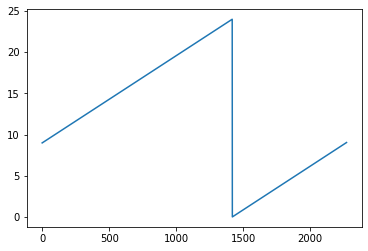

In [35]:
plt.plot(l2_data_cut.previous_level[i].ancillary["lst"])
l2_data_cut.spectrum[6,200,:]

'\nfor i in range(5,10):\n    plt.plot(l2_data_cut.previous_level[i].spectrum[index,:],label=str(i))\nplt.legend()\n'

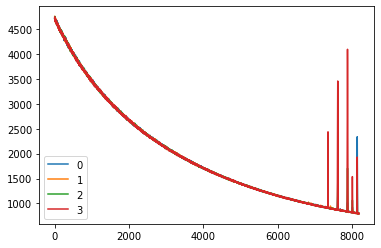

In [61]:
index = (np.where(l2_data_cut.previous_level[i].ancillary["gha"]>10)[0][0])
index_2 = (np.where(gha_2>10)[0][0])
for i in range(0,4):
    plt.plot(l2_data_cut.spectrum[i,index_2,:],label=str(i))
plt.legend()
'''
for i in range(5,10):
    plt.plot(l2_data_cut.previous_level[i].spectrum[index,:],label=str(i))
plt.legend()
'''

In [64]:
level1 = l2_data_cut.previous_level
gha_edges = gha_2
# Averaging data within GHA bins
weights = np.zeros((len(level1), len(gha_edges) - 1, level1[0].freq.n))
spectra = np.zeros((len(level1), len(gha_edges) - 1, level1[0].freq.n))

for i, l1 in enumerate(level1):
    #pbar.set_description(f"GHA Binning for {l1.filename.name}")

    gha = l1.ancillary["gha"]

    for j, gha_low in enumerate(gha_edges[:-1]):

        mask = (gha >= gha_low) & (gha < gha_edges[j + 1])
        spec = l1.spectrum[mask]
        #wght = l1.weights[mask]
        spectra[i, j] = np.mean(spec,axis=0)
        '''
        if np.any(wght):
            spec_mean, wght_mean = tools.weighted_mean(spec, weights=wght, axis=0)

            # Store this iteration
            spectra[i, j] = np.mean(spec,axis=0)#spec_mean
            weights[i, j] = wght_mean
        '''

/home/nmahesh/miniconda3/envs/edges/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3334: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nmahesh/miniconda3/envs/edges/lib/python3.8/site-packages/numpy/core/_methods.py:153: RuntimeWarning: invalid value encountered in true_divide
  ret = um.true_divide(


Level1(filename=PosixPath('/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_273_15_47_58.h5'), require_all=True, require_no_extra=True, always_lazy=False, lazy=True)

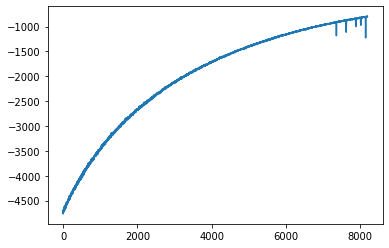

In [99]:
#for i in range():
plt.plot(l2_data_cut.spectrum[9,index_2,:] - spectra[17,index_2,:])

level1[8]
#plt.plot(l2_data_cut.spectrum[0,index_2,:])

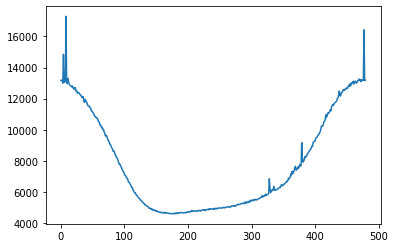

In [50]:
plt.plot(l2_data_cut.spectrum[6,:,0])

In [5]:
l2_data_cut.

[Level1(filename=PosixPath('/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_287_00_00_21.h5'), require_all=True, require_no_extra=True, always_lazy=False, lazy=True),
 Level1(filename=PosixPath('/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_285_00_00_02.h5'), require_all=True, require_no_extra=True, always_lazy=False, lazy=True),
 Level1(filename=PosixPath('/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_286_00_00_19.h5'), require_all=True, require_no_extra=True, always_lazy=False, lazy=True),
 Level1(filename=PosixPath('/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_289_00_00_18.h5'), require_all=True, require_no_extra=True, always_lazy=False, lazy=True),
 Level1(filename=PosixPath('/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_278_00_00_12.h5'), require_all=True, require_no_extra=True, always_lazy=False, lazy=True),
 Level1(filename=PosixPath('/data4/nmahesh/edges/edges-field-levels/level1/level1_par

In [11]:
l2_data_cut.meta

{'ambient_humidity_max': 40,
 'edges_analysis_version': '1.0.0.post0.dev14+g7dbcbd3.dirty',
 'gha_bin_size': 0.05,
 'gha_max': 24.0,
 'gha_min': 0.0,
 'max_receiver_temp': 100,
 'message': '',
 'min_receiver_temp': 0,
 'moon_el_max': 90,
 'n_files': 18,
 'n_files_flagged': 7,
 'object_name': 'Level2',
 'prev_level_files': '/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_287_00_00_21.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_285_00_00_02.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_286_00_00_19.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_289_00_00_18.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_278_00_00_12.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_279_00_00_04.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_281_00_00_12.h5:/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_274_00_00_04.h5:/data4/nmahesh/edges/edges-field-le